# A)
Import dataset 'diabetes.csv'. Scale data and use the sklearn KMeans method to perform the K-means clustering with $K=5$. Repeat the experiment many times and observe the results. Exploit the PCA to plot clusters from a 8-dimensional space to a 2-dimensional plane.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

data = pd.read_csv('./data_ex3.1/diabetes.csv', delimiter=';')
print(data)

     preg  plas   pres   skin   insu   mass   pedi   age
0       6   148     72     35      0   33.6   0.63    50
1       1    85     66     29      0   26.6   0.35    31
2       8   183     64      0      0   23.3   0.67    32
3       1    89     66     23     94   28.1   0.17    21
4       0   137     40     35    168   43.1   2.29    33
..    ...   ...    ...    ...    ...    ...    ...   ...
763    10   101     76     48    180   32.9   0.17    63
764     2   122     70     27      0   36.8   0.34    27
765     5   121     72     23    112   26.2   0.25    30
766     1   126     60      0      0   30.1   0.35    47
767     1    93     70     31      0   30.4   0.32    23

[768 rows x 8 columns]


In [4]:
scaler = StandardScaler()
scaler.fit(data)
data_scaled = scaler.transform(data)
print(data_scaled)
print(f'mean of scaled features {np.mean(data_scaled,0)}')
print(f'st.dev. of scaled features {np.std(data_scaled,0)}')

[[ 0.63994726  0.84832379  0.14964075 ...  0.20401277  0.47610833
   1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575 ... -0.68442195 -0.36974705
  -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 ... -1.10325546  0.59694482
  -0.10558415]
 ...
 [ 0.3429808   0.00330087  0.14964075 ... -0.73518964 -0.67183826
  -0.27575966]
 [-0.84488505  0.1597866  -0.47073225 ... -0.24020459 -0.36974705
   1.17073215]
 [-0.84488505 -0.8730192   0.04624525 ... -0.20212881 -0.46037442
  -0.87137393]]
mean of scaled features [-6.47630098e-17 -9.25185854e-18  1.50342701e-17  1.00613962e-16
 -3.00685403e-17  2.59052039e-16 -2.77555756e-17  1.93132547e-16]
st.dev. of scaled features [1. 1. 1. 1. 1. 1. 1. 1.]


In [15]:
K = 5
kmeans_model = KMeans(n_clusters=K, init='random', n_init=10)
kmeans_model.fit(data_scaled)
y = kmeans_model.labels_
print(f'obtained clustering \n {y}\n')
print(f'clusters centroids\n {kmeans_model.cluster_centers_}\n')
print(f'final overall distance points-centroids {kmeans_model.inertia_}')

obtained clustering 
 [3 0 4 0 1 4 0 2 1 4 4 4 4 1 3 2 1 4 0 0 1 4 4 3 3 3 4 0 3 4 3 1 0 4 3 0 4
 3 0 3 1 4 4 3 4 1 0 0 3 2 0 0 0 3 1 0 1 1 4 1 2 4 0 1 4 0 0 4 0 0 0 1 4 1
 0 0 4 0 2 0 0 2 3 0 4 0 3 0 3 0 0 0 3 4 0 3 0 0 0 1 4 0 0 0 0 1 0 1 0 0 1
 1 0 0 3 4 4 0 0 0 1 0 0 4 0 1 1 0 1 4 1 4 1 3 0 0 0 0 0 1 4 3 0 4 1 0 3 1
 4 0 1 4 3 1 4 3 0 0 0 3 3 3 1 0 0 3 0 4 0 0 4 1 2 0 0 3 4 1 4 4 4 0 0 0 4
 3 3 1 3 1 0 3 4 2 4 1 0 0 1 1 0 4 0 0 3 0 3 4 0 3 0 1 3 1 3 3 1 3 0 4 1 4
 2 3 0 0 0 1 1 0 4 1 0 4 0 4 3 1 3 0 0 0 0 1 1 3 4 1 1 0 4 0 0 0 3 0 0 0 1
 3 1 2 0 4 4 3 2 1 0 2 3 0 4 0 4 1 0 0 4 0 0 3 3 4 4 3 1 1 0 3 0 0 1 1 4 1
 1 1 3 4 2 1 0 4 4 1 3 0 1 1 0 1 0 0 3 0 0 4 1 4 0 0 0 3 0 0 1 4 1 3 3 0 2
 4 0 1 2 4 3 4 0 0 0 4 4 3 0 2 0 0 4 4 0 0 0 4 1 2 3 1 1 4 3 4 1 0 4 0 0 1
 1 0 0 0 1 3 0 0 4 1 0 0 0 0 0 0 3 3 3 0 1 4 1 0 4 1 0 0 0 1 0 4 3 3 4 1 4
 0 4 1 3 1 1 0 1 1 0 3 0 0 1 0 1 0 3 1 2 1 1 0 2 0 0 4 0 2 3 4 0 4 1 0 0 4
 0 1 0 0 0 0 0 0 1 2 0 3 4 0 3 3 3 0 3 0 4 0 0 0 2 1 1 0 0 4 0 4 1 0 3 3 1
 0 

3625.6425989817944


/tmp/ipykernel_12673/3352934323.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap=plt.cm.get_cmap('inferno',5))


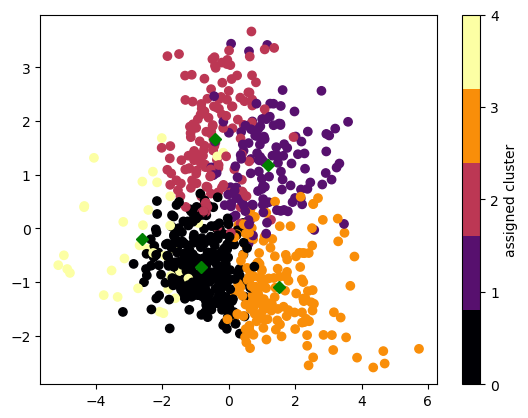

In [23]:
kmeans_model = KMeans(n_clusters=K, init='random', n_init=10)
kmeans_model.fit(data_scaled)
y = kmeans_model.labels_
pca_model = PCA(n_components=2)
pca_coordinates = pca_model.fit_transform(data_scaled)
pca_centroids = pca_model.transform(kmeans_model.cluster_centers_)
plt.scatter(pca_coordinates[:, 0], pca_coordinates[:, 1], c=y,\
            cmap=plt.cm.get_cmap('inferno',5))
plt.colorbar(ticks=range(5), label='assigned cluster')
for i in range(K):
    plt.plot(pca_centroids[i,0], pca_centroids[i,1] ,'gD') 
print(kmeans_model.inertia_)

# B)
Compute the silhouette score and construct the silhouette plot for the last determined clustering.

overall clustering silhouette 0.1884951869608038


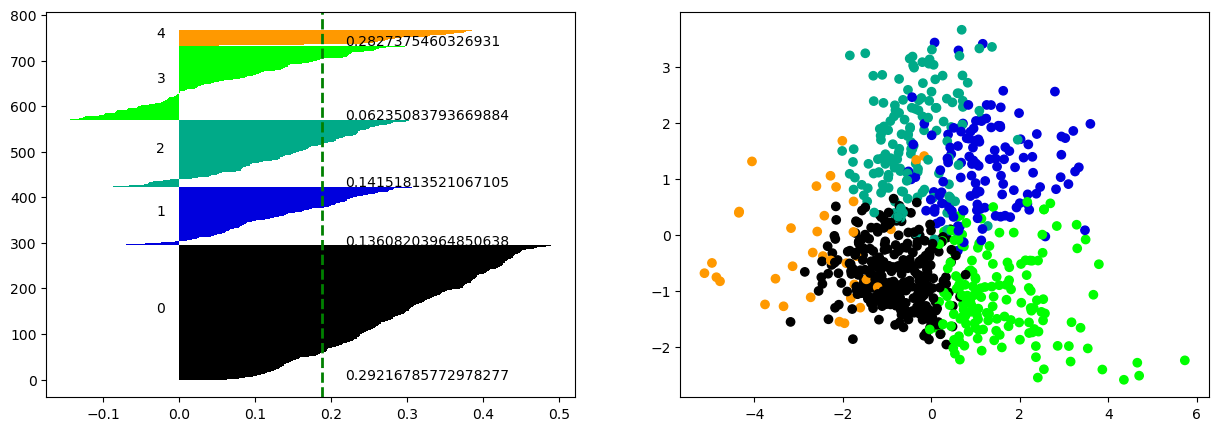

In [24]:
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm

silhouette_avg = silhouette_score(data_scaled, y)
sample_silhouette_values = silhouette_samples(data_scaled, y)

print(f'overall clustering silhouette {silhouette_avg}')

fig, ax = plt.subplots(1,2,figsize=(15,5))
y_lower = 0 
y_upper = 0
for i,cluster in enumerate(np.unique(y)):
    cluster_silhouette_vals = sample_silhouette_values[y == cluster]
    cluster_silhouette_vals.sort()
    cluster_silhouette_mean=cluster_silhouette_vals.mean()
    y_upper += len(cluster_silhouette_vals)
    color = cm.nipy_spectral(float(i) / K)
    ax[0].barh(range(y_lower,y_upper), cluster_silhouette_vals, height=1, color=color)
    ax[0].text(-0.03, (y_lower+y_upper)/2, str(i))
    ax[0].text(silhouette_avg+0.03, y_lower, cluster_silhouette_mean)  
    y_lower += len(cluster_silhouette_vals)

ax[0].axvline(silhouette_avg, linestyle ='--', linewidth =2, color = 'green')
colors = cm.nipy_spectral(y.astype(float) / K)
ax[1].scatter(pca_coordinates[:, 0], pca_coordinates[:, 1], c=colors)

